## Ejercicio 1 
--- 

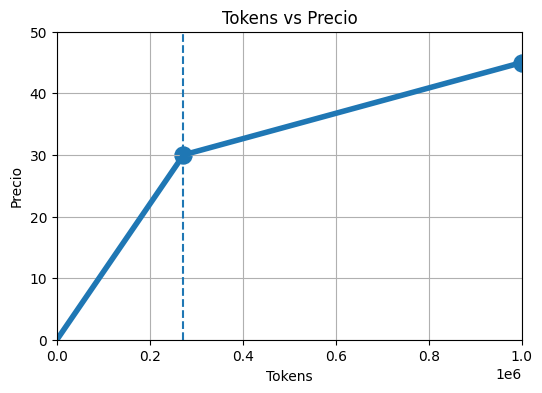

In [52]:
import numpy as np
import matplotlib.pyplot as plt

tokens = list(range(1_000_000))

m1 = 30 / 272000

m2 = (45 - 30) / (1_000_000 - 272_000)

precio = []

for t in tokens:

    if t <= 272000:

        y = m1 * t

    else:

        y = m2 * (t - 272000) + 30

    precio.append(y)

plt.figure(figsize=(6,4))

plt.plot(tokens, precio,
         linewidth=4)

plt.scatter([272000, 1000000],
            [30, 45],
            s=150)

plt.axvline(x=272000,
            linestyle='--')

plt.xlim(0, 1_000_000)
plt.ylim(0, 50)

plt.xlabel("Tokens")
plt.ylabel("Precio")

plt.title("Tokens vs Precio")

plt.grid(True)

plt.show()

## **Ejercicio 2**
---
Encontrar todas las raíces de la ecuación $f(x)=\frac{1}{4}(x^3+3x^2-6x-8)$
 usando el método de la bisección. Grafique. Modifique el número de iteraciones a 5. Pruebe los siguientes rangos de búsqueda ([-5 3], [-4.7 2.5], [-4.5 2.7], [-3 -2]).  


Éxito en rango [-5, 3]: Punto medio -1.000000
Fracasó en rango [-4.025, -3.8000000000000003] tras 5 iteraciones.
Fracasó en rango [1.8000000000000003, 2.0250000000000004] tras 5 iteraciones.
Rango [-3, -2]: f(a) y f(b) deben tener signos opuestos.


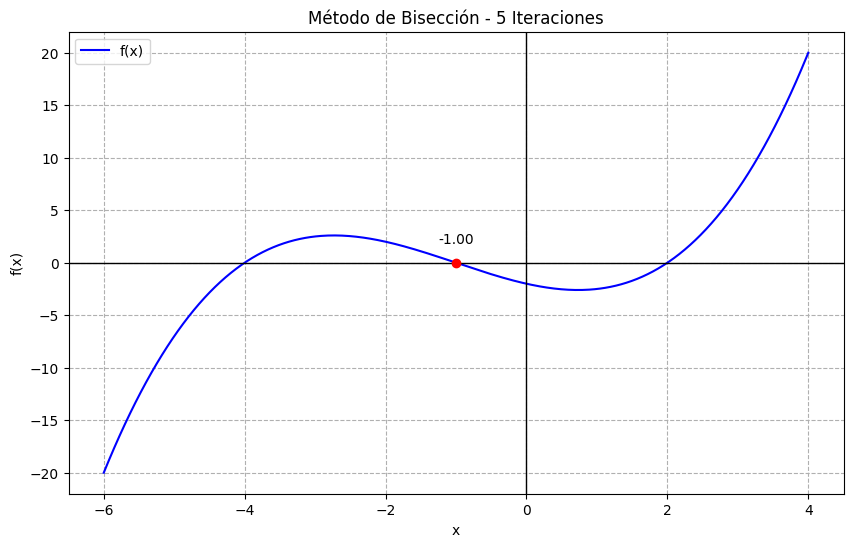

In [61]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
  
    return 0.25 * (x**3 + 3*x**2 - 6*x - 8)

def biseccion(limiteA, limiteB, tolerancia, numeroRepeticiones):
    
    i = 1
    imagenDeA = f(limiteA)
    
    
    if f(limiteA) * f(limiteB) >= 0:
        print(f'Rango [{limiteA}, {limiteB}]: f(a) y f(b) deben tener signos opuestos.')
        return None

   
    while i <= numeroRepeticiones:
        
        puntoMedio = limiteA + (limiteB - limiteA) / 2 
        imagenPuntoMedio = f(puntoMedio)

        
        if imagenPuntoMedio == 0 or (limiteB - limiteA) / 2 < tolerancia:
            print(f'Éxito en rango [{limiteA}, {limiteB}]: Punto medio {puntoMedio:.6f}')
            return puntoMedio 

        
        i += 1 

        
        if imagenDeA * imagenPuntoMedio > 0: 
            limiteA = puntoMedio
            imagenDeA = imagenPuntoMedio
        else:
            limiteB = puntoMedio 
            
    print(f'Fracasó en rango [{limiteA}, {limiteB}] tras {numeroRepeticiones} iteraciones.')
    return None

# Parámetros
numeroRepeticiones = 5
tolerancia = 0.0001
rangos = [[-5, 3], [-4.7, 2.5], [-4.5, 2.7], [-3, -2]]
raicesEncontradas = []

for rango in rangos:
    res = biseccion(rango[0], rango[1], tolerancia, numeroRepeticiones)
    if res is not None:
        raicesEncontradas.append(res)


x_vals = np.linspace(-6, 4, 400)
y_vals = f(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label="f(x)", color='blue')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)


for raiz in set(np.round(raicesEncontradas, 4)):
    plt.plot(raiz, 0, 'ro') 
    plt.annotate(f"{raiz:.2f}", (raiz, 0.5), textcoords="offset points", xytext=(0,10), ha='center')

plt.title("Método de Bisección - 5 Iteraciones")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, linestyle='--')
plt.legend()
plt.show()